In [1]:
import pandas, numpy, sklearn, xgboost, lightgbm, shap, lime, matplotlib, seaborn, scipy, statsmodels
print("Tat ca thu vien da san sang!")


Tat ca thu vien da san sang!


In [4]:
import pandas as pd
import numpy as np

df_raw = pd.read_csv('data/online_retail_II.csv', encoding='ISO-8859-1')
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])
if 'CustomerID' in df_raw.columns:
    df_raw = df_raw.rename(columns={'CustomerID': 'Customer ID'})
print(df_raw.shape)

(1067371, 8)


In [5]:
df_raw['is_cancelled'] = df_raw['Invoice'].astype(str).str.startswith('C')

def lam_sach_du_lieu(df_input):
    df = df_input.copy()
    df['Invoice'] = df['Invoice'].astype(str)
    df = df[~df['Invoice'].str.startswith('C')]
    non_product_codes = ['POST', 'D', 'M', 'BANK CHARGES', 'DOT', 'ADJUST', 'ADJUST2', 'CRUK']
    df = df[~df['StockCode'].astype(str).isin(non_product_codes)]
    df = df.dropna(subset=['Customer ID'])
    df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
    df = df.drop_duplicates()
    df['Revenue'] = df['Quantity'] * df['Price']
    return df.reset_index(drop=True)

df_clean = lam_sach_du_lieu(df_raw)
print(df_clean.shape)

(776854, 10)


In [7]:
cutoff_date = pd.Timestamp('2011-06-01')
obs_for_country = df_clean[df_clean['InvoiceDate'] < cutoff_date]
TOP_COUNTRIES = obs_for_country['Country'].value_counts().head(8).index.tolist()
print(TOP_COUNTRIES)

def tinh_dac_trung_nang_cao(df_raw_input, df_clean_input, cutoff_date, top_countries):
    obs_clean = df_clean_input[df_clean_input['InvoiceDate'] < cutoff_date].copy()
    obs_raw = df_raw_input[df_raw_input['InvoiceDate'] < cutoff_date].copy()

    # --- RFM co ban ---
    rfm = obs_clean.groupby('Customer ID').agg(
        Recency=('InvoiceDate', lambda x: (cutoff_date - x.max()).days),
        Frequency=('Invoice', 'nunique'),
        Monetary=('Revenue', 'sum'),
        AvgOrderValue=('Revenue', 'mean'),
        NumProducts=('StockCode', 'nunique'),
        FirstPurchase=('InvoiceDate', 'min'),
        Country=('Country', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'),
    ).reset_index()

    # --- ĐÃ SỬA LỖI: Dùng np.sort() thay vì sorted() ---
    def std_khoang_cach(dates):
        d = np.sort(dates.unique()) 
        if len(d) < 3:
            return np.nan
        diffs = np.diff(d) / np.timedelta64(1, 'D')
        return float(np.std(diffs))
        
    interval_std = (obs_clean.groupby('Customer ID')['InvoiceDate']
                     .apply(std_khoang_cach).rename('IntervalStd').reset_index())

    # --- Xu huong chi tieu VA xu huong tan suat (3 thang gan vs 3 thang truoc) ---
    mid_point = cutoff_date - pd.Timedelta(days=90)
    far_point = cutoff_date - pd.Timedelta(days=180)
    rev_recent = obs_clean[obs_clean['InvoiceDate'] >= mid_point].groupby('Customer ID')['Revenue'].sum()
    rev_prev = obs_clean[(obs_clean['InvoiceDate'] >= far_point) & (obs_clean['InvoiceDate'] < mid_point)].groupby('Customer ID')['Revenue'].sum()
    freq_recent = obs_clean[obs_clean['InvoiceDate'] >= mid_point].groupby('Customer ID')['Invoice'].nunique()
    freq_prev = obs_clean[(obs_clean['InvoiceDate'] >= far_point) & (obs_clean['InvoiceDate'] < mid_point)].groupby('Customer ID')['Invoice'].nunique()
    trend = pd.concat([rev_recent.rename('rev_recent'), rev_prev.rename('rev_prev'),
                        freq_recent.rename('freq_recent'), freq_prev.rename('freq_prev')], axis=1).fillna(0)
    trend['SpendingTrend'] = trend['rev_recent'] - trend['rev_prev']
    trend['FrequencyTrend'] = trend['freq_recent'] - trend['freq_prev']
    trend = trend[['SpendingTrend', 'FrequencyTrend']].reset_index()

    # --- Ty le huy don ---
    total_invoices = obs_raw.groupby('Customer ID')['Invoice'].nunique().rename('TotalInvoices')
    cancelled_invoices = (obs_raw[obs_raw['is_cancelled']]
                          .groupby('Customer ID')['Invoice'].nunique().rename('CancelledInvoices'))
    cancel_df = pd.concat([total_invoices, cancelled_invoices], axis=1).fillna(0)
    cancel_df['CancelRate'] = cancel_df['CancelledInvoices'] / cancel_df['TotalInvoices'].replace(0, np.nan)
    cancel_df = cancel_df[['CancelRate']].fillna(0).reset_index()

    # --- Gop tat ca ---
    features = rfm.merge(interval_std, on='Customer ID', how='left')
    features = features.merge(trend, on='Customer ID', how='left')
    features = features.merge(cancel_df, on='Customer ID', how='left')
    features['IntervalStd'] = features['IntervalStd'].fillna(features['IntervalStd'].median())
    features[['SpendingTrend', 'FrequencyTrend', 'CancelRate']] = features[['SpendingTrend', 'FrequencyTrend', 'CancelRate']].fillna(0)

    # --- RepeatPurchaseRatio ---
    tenure_months = ((cutoff_date - features['FirstPurchase']).dt.days / 30.44).clip(lower=1)
    active_months_series = (obs_clean.assign(ym=obs_clean['InvoiceDate'].dt.to_period('M'))
                             .groupby('Customer ID')['ym'].nunique().rename('ActiveMonths'))
    features = features.merge(active_months_series, on='Customer ID', how='left')
    features['ActiveMonths'] = features['ActiveMonths'].fillna(1)
    features['RepeatPurchaseRatio'] = (features['ActiveMonths'] / tenure_months).clip(upper=1.0)

    # --- Country_grouped + One-Hot Encoding ---
    features['Country_grouped'] = features['Country'].where(features['Country'].isin(top_countries), 'Other')
    country_dummies = pd.get_dummies(features['Country_grouped'], prefix='Country', drop_first=True).astype(int)

    features_final = pd.concat([features.drop(columns=['FirstPurchase', 'Country', 'Country_grouped', 'ActiveMonths']),
                                 country_dummies], axis=1)
    return features_final

features = tinh_dac_trung_nang_cao(df_raw, df_clean, cutoff_date, TOP_COUNTRIES)
print(features.shape)
features.head()

['United Kingdom', 'EIRE', 'Germany', 'France', 'Netherlands', 'Spain', 'Switzerland', 'Belgium']
(4909, 19)


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,NumProducts,IntervalStd,SpendingTrend,FrequencyTrend,CancelRate,RepeatPurchaseRatio,Country_EIRE,Country_France,Country_Germany,Country_Netherlands,Country_Other,Country_Spain,Country_Switzerland,Country_United Kingdom
0,12346.0,133,12,77556.46,2281.072353,27,62.465633,-77183.60,-1.0,0.294118,0.285553,0,0,0,0,0,0,0,1
1,12347.0,54,4,2434.96,19.636774,90,13.930779,-550.93,-1.0,0.000000,0.574340,0,0,0,0,1,0,0,0
2,12348.0,56,4,1388.40,31.554545,24,17.215056,-513.24,-1.0,0.000000,0.494959,0,0,0,0,1,0,0,0
3,12349.0,215,2,2221.14,22.211400,89,36.034375,0.00,0.0,0.250000,0.153350,0,0,0,0,1,0,0,0
4,12350.0,118,1,294.40,18.400000,16,36.034375,-294.40,-1.0,0.000000,0.257966,0,0,0,0,1,0,0,0


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb
import lightgbm as lgb

# 1. Gán nhãn khách hàng có rời đi (churn) hay không
def kiem_tra_va_gan_nhan(df_clean_input, cutoff_date, churn_window_days, max_date_input):
    required_end = cutoff_date + pd.Timedelta(days=churn_window_days)
    if required_end > max_date_input: return None, False
    obs = df_clean_input[df_clean_input['InvoiceDate'] < cutoff_date]
    future = df_clean_input[(df_clean_input['InvoiceDate'] >= cutoff_date) & (df_clean_input['InvoiceDate'] < required_end)]
    customers_before = obs['Customer ID'].unique()
    if len(customers_before) == 0: return None, False
    active_future = set(future['Customer ID'].unique())
    labels = pd.Series([0 if c in active_future else 1 for c in customers_before], index=customers_before, name='churn')
    return labels, True
 
max_date = df_clean['InvoiceDate'].max()
min_date = df_clean['InvoiceDate'].min()
cutoff_candidates = pd.date_range(start=min_date + pd.DateOffset(months=8), end=max_date - pd.DateOffset(months=7), freq='2MS')
valid_cutoffs = [c for c in cutoff_candidates if kiem_tra_va_gan_nhan(df_clean, c, 90, max_date)[1]]

walk_forward_folds = [(valid_cutoffs[i], valid_cutoffs[i+1], valid_cutoffs[i+2]) for i in range(len(valid_cutoffs) - 2)]

# 2. Xử lý sẵn dữ liệu cho từng mốc thời gian (Caching)
def chuan_bi_du_lieu_cho_cutoff(cutoff, churn_window_days=90):
    feats = tinh_dac_trung_nang_cao(df_raw, df_clean, cutoff, TOP_COUNTRIES)
    labels, is_valid = kiem_tra_va_gan_nhan(df_clean, cutoff, churn_window_days, max_date)
    return feats.merge(labels.rename('churn'), left_on='Customer ID', right_index=True)
 
all_cutoffs_needed = sorted(set([c for fold in walk_forward_folds for c in fold]))
print("Đang xử lý đặc trưng cho từng cột mốc (mất khoảng 1 phút)...")
data_cache = {c: chuan_bi_du_lieu_cho_cutoff(c) for c in all_cutoffs_needed}
feature_cols = [c for c in data_cache[all_cutoffs_needed[0]].columns if c not in ('Customer ID', 'churn')]

# 3. Định nghĩa mô hình và Huấn luyện
model_configs = {
    'LogisticRegression': {
        'builder': lambda p, s: LogisticRegression(random_state=s, class_weight='balanced', max_iter=1000, **p),
        'param_grid': [{'C': 0.1}, {'C': 1.0}], 'needs_scaling': True
    },
    'RandomForest': {
        'builder': lambda p, s: RandomForestClassifier(random_state=s, class_weight='balanced', **p),
        'param_grid': [{'n_estimators': 200, 'max_depth': 5}, {'n_estimators': 300, 'max_depth': 8}], 'needs_scaling': False
    },
    'XGBoost': {
        'builder': lambda p, s: xgb.XGBClassifier(random_state=s, eval_metric='logloss', **p),
        'param_grid': [{'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}, {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05}], 'needs_scaling': False
    },
    'LightGBM': {
        'builder': lambda p, s: lgb.LGBMClassifier(random_state=s, verbose=-1, **p),
        'param_grid': [{'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}, {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05}], 'needs_scaling': False
    },
}
 
def walk_forward_evaluate(model_name, config, feature_cols, seeds=(0, 1, 2)):
    fold_results = []
    for fold_idx, (train_c, val_c, test_c) in enumerate(walk_forward_folds):
        train_data, val_data, test_data = data_cache[train_c], data_cache[val_c], data_cache[test_c]
        Xtr, Xval, Xte = train_data[feature_cols].copy(), val_data[feature_cols].copy(), test_data[feature_cols].copy()
 
        if config['needs_scaling']:
            scaler = StandardScaler()
            Xtr = pd.DataFrame(scaler.fit_transform(Xtr), columns=feature_cols)
            Xval = pd.DataFrame(scaler.transform(Xval), columns=feature_cols)
            Xte = pd.DataFrame(scaler.transform(Xte), columns=feature_cols)
 
        for seed in seeds:
            best_auc, best_params = -1, config['param_grid'][0]
            for params in config['param_grid']:
                model = config['builder'](params, seed)
                model.fit(Xtr, train_data['churn'])
                val_auc = roc_auc_score(val_data['churn'], model.predict_proba(Xval)[:, 1])
                if val_auc > best_auc: best_auc, best_params = val_auc, params
 
            final_model = config['builder'](best_params, seed)
            final_model.fit(Xtr, train_data['churn'])
            test_prob = final_model.predict_proba(Xte)[:, 1]
            fold_results.append({
                'model': model_name, 'fold': fold_idx, 'seed': seed,
                'roc_auc': roc_auc_score(test_data['churn'], test_prob),
                'pr_auc': average_precision_score(test_data['churn'], test_prob),
            })
    return pd.DataFrame(fold_results)

# Bắt đầu chạy cả 4 mô hình (Quá trình này tốn từ 2-4 phút)
all_results = []
for name, config in model_configs.items():
    print(f"Đang huấn luyện mô hình {name}...")
    all_results.append(walk_forward_evaluate(name, config, feature_cols))
 
results_df = pd.concat(all_results, ignore_index=True)
print("Hoàn tất huấn luyện!")

Đang xử lý đặc trưng cho từng cột mốc (mất khoảng 1 phút)...
Đang huấn luyện mô hình LogisticRegression...
Đang huấn luyện mô hình RandomForest...
Đang huấn luyện mô hình XGBoost...
Đang huấn luyện mô hình LightGBM...
Hoàn tất huấn luyện!


In [12]:
from scipy.stats import wilcoxon

# 1. Bảng điểm số ROC-AUC và PR-AUC
print("=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ===")
print(results_df.groupby('model')[['roc_auc', 'pr_auc']].agg(['mean', 'std']))

# 2. So sánh ý nghĩa thống kê giữa LR và XGBoost
pivot_auc = results_df.pivot_table(index=['fold', 'seed'], columns='model', values='roc_auc')
stat, p_value = wilcoxon(pivot_auc['LogisticRegression'], pivot_auc['XGBoost'])
print(f"\nSo sánh p-value (LR vs XGBoost) = {p_value:.4f}")

# 3. Ablation Study: Đánh giá giá trị của việc thêm tính năng mới
basic_cols = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'NumProducts']
print("\nĐang chạy Ablation Study kiểm tra hiệu quả nhóm tính năng RFM nâng cao...")
res_basic = walk_forward_evaluate('RF_basic', model_configs['RandomForest'], basic_cols)
res_full = walk_forward_evaluate('RF_full', model_configs['RandomForest'], feature_cols)

print(f"RFM cơ bản : {res_basic['roc_auc'].mean():.4f}")
print(f"RFM đầy đủ : {res_full['roc_auc'].mean():.4f}")
stat_abl, p_abl = wilcoxon(res_basic['roc_auc'], res_full['roc_auc'])
print(f"Wilcoxon p-value cho Ablation = {p_abl:.4f}")

=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ===
                     roc_auc              pr_auc          
                        mean       std      mean       std
model                                                     
LightGBM            0.745744  0.014945  0.821385  0.011202
LogisticRegression  0.783969  0.007506  0.854862  0.008316
RandomForest        0.782401  0.006330  0.853193  0.005494
XGBoost             0.749880  0.017696  0.824884  0.014440

So sánh p-value (LR vs XGBoost) = 0.0039

Đang chạy Ablation Study kiểm tra hiệu quả nhóm tính năng RFM nâng cao...
RFM cơ bản : 0.7718
RFM đầy đủ : 0.7824
Wilcoxon p-value cho Ablation = 0.0039


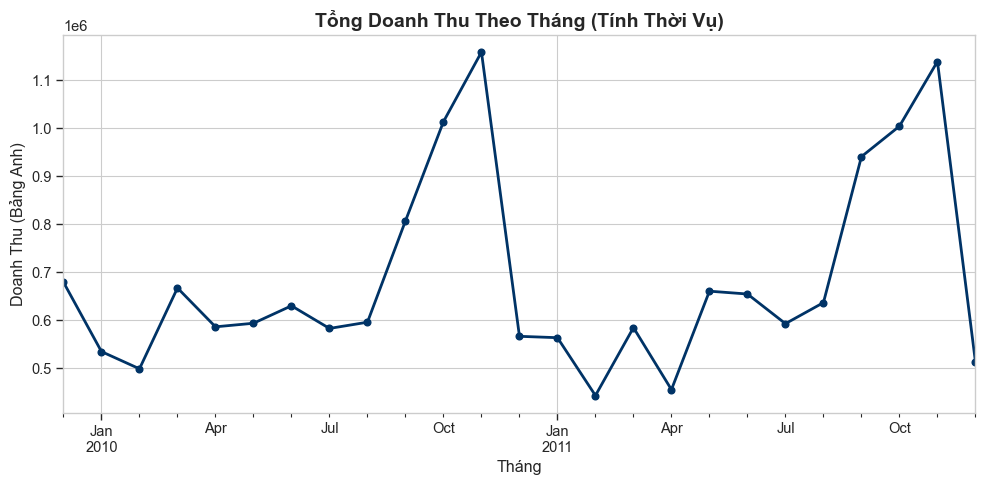

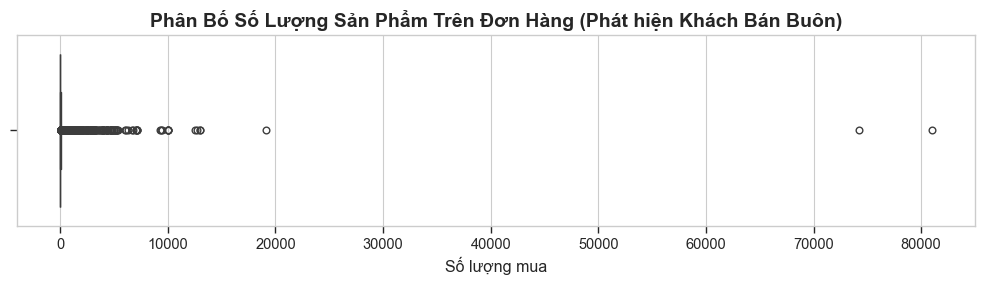

C:\Users\ngoct\AppData\Local\Temp\ipykernel_1328\680930083.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_countries.index, x=top_countries.values, palette='Blues_r')


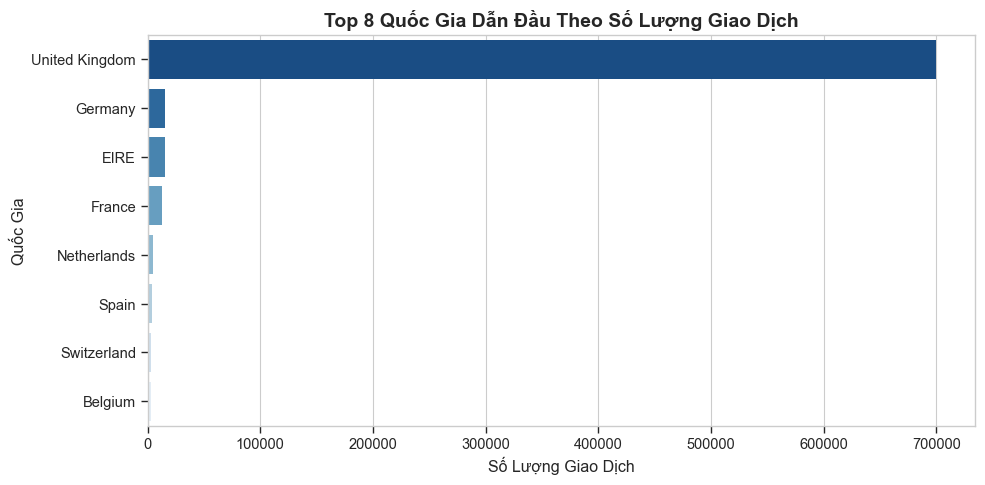

Đã lưu thành công 3 biểu đồ vào thư mục làm việc hiện tại!


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cài đặt phông chữ và phong cách chuẩn học thuật
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# --- Biểu đồ 1: Tính thời vụ (Doanh thu theo tháng) ---
plt.figure(figsize=(10, 5))
monthly_revenue = df_clean.set_index('InvoiceDate').resample('ME')['Revenue'].sum()
ax1 = monthly_revenue.plot(kind='line', marker='o', color='#003366', linewidth=2)
plt.title('Tổng Doanh Thu Theo Tháng (Tính Thời Vụ)', fontsize=14, fontweight='bold')
plt.ylabel('Doanh Thu (Bảng Anh)')
plt.xlabel('Tháng')
plt.tight_layout()
plt.savefig('Bieu_Do_1_Thoi_Vu.png', dpi=300) # Lưu hình 1
plt.show()

# --- Biểu đồ 2: Khách sỉ vs Khách lẻ (Boxplot Quantity) ---
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_clean['Quantity'], color='#0066cc')
plt.title('Phân Bố Số Lượng Sản Phẩm Trên Đơn Hàng (Phát hiện Khách Bán Buôn)', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng mua')
plt.tight_layout()
plt.savefig('Bieu_Do_2_Khach_Si.png', dpi=300) # Lưu hình 2
plt.show()

# --- Biểu đồ 3: Sự thống trị của thị trường Nội địa ---
plt.figure(figsize=(10, 5))
top_countries = df_clean['Country'].value_counts().head(8)
sns.barplot(y=top_countries.index, x=top_countries.values, palette='Blues_r')
plt.title('Top 8 Quốc Gia Dẫn Đầu Theo Số Lượng Giao Dịch', fontsize=14, fontweight='bold')
plt.xlabel('Số Lượng Giao Dịch')
plt.ylabel('Quốc Gia')
plt.tight_layout()
plt.savefig('Bieu_Do_3_Quoc_Gia.png', dpi=300) # Lưu hình 3
plt.show()

print("Đã lưu thành công 3 biểu đồ vào thư mục làm việc hiện tại!")

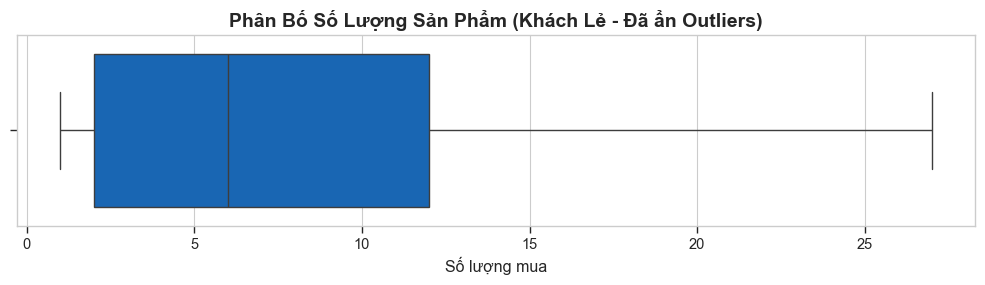

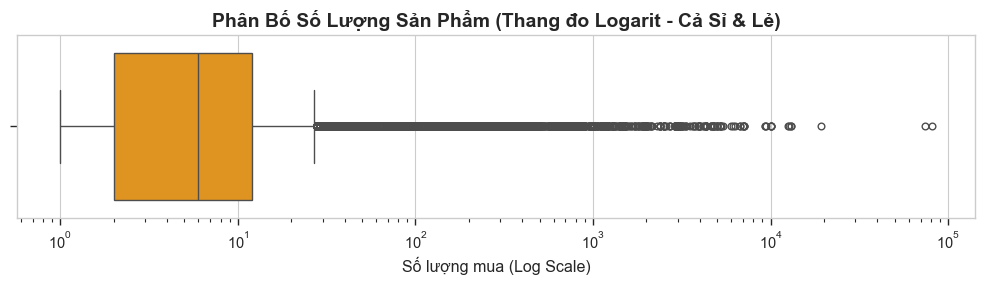

Đã lưu thành công 2 phiên bản mới của Biểu đồ 2!


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt lại style cho đẹp
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# ==========================================
# CÁCH 1: ẨN NGOẠI LAI (Tập trung vào nhóm khách mua lẻ B2C)
# ==========================================
plt.figure(figsize=(10, 3))
# Tham số showfliers=False sẽ giấu các chấm đen khổng lồ đi
sns.boxplot(x=df_clean['Quantity'], showfliers=False, color='#0066cc')
plt.title('Phân Bố Số Lượng Sản Phẩm (Khách Lẻ - Đã ẩn Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng mua')
plt.tight_layout()
plt.savefig('Bieu_Do_2_Khach_Le.png', dpi=300)
plt.show()


# ==========================================
# CÁCH 2: THANG ĐO LOGARIT (Nhìn được cả khách Sỉ và Lẻ)
# ==========================================
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_clean['Quantity'], color='#ff9900')
# Chuyển trục X sang thang đo Logarit (nén khoảng cách các số siêu lớn lại)
plt.xscale('log') 
plt.title('Phân Bố Số Lượng Sản Phẩm (Thang đo Logarit - Cả Sỉ & Lẻ)', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng mua (Log Scale)')
plt.tight_layout()
plt.savefig('Bieu_Do_2_Khach_Si_Le.png', dpi=300)
plt.show()

print("Đã lưu thành công 2 phiên bản mới của Biểu đồ 2!")